# Import Zone

In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import sys
from pathlib import Path
import json
from lmfit import Model
from matplotlib.ticker import MaxNLocator
from itertools import accumulate



import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'


project_root = Path.cwd().parent.parent
sys.path.append(str(project_root / "src"))


from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2
from QLS.state_dist import States
from BayesianSE.estimator import BayesianStateEstimation

from pumping.pump_evolution import run_pumping
from state_preparation import run_pumping_pipeline
from BayesianSE.main import run_bayesian_state_estimation
from BayesianSE._plotting import plot_method_comparison

from BayesianSE.estimator_measurements import meas_sensitivity_heatmap

# CaH

In [2]:
b_field_gauss = 3.6
j_max = 14
temperature = 300

molecule = CaH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = States(molecule, temperature)

Saved molecule data in:
/home/stripzio/bayesian-qls/project/molecule_data/CaH_B[3.60]_Jmax[14]_states.csv
/home/stripzio/bayesian-qls/project/molecule_data/CaH_B[3.60]_Jmax[14]_transitions.csv


In [3]:
indices_leftmost = [2*(2*j+1) for j in range(j_max)]
indices_leftmost = [0] + list(accumulate(indices_leftmost))

lower_indices = [idx + (2*i+1) for i, idx in enumerate(indices_leftmost)]

indices_penultimate_upper = [ind+1 for ind in indices_leftmost] 
indices_thirdultimate_upper = [ind+2 for ind in indices_leftmost]
indices_fourthultimate_upper = [ind+3 for ind in indices_leftmost]
indices_fifthultimate_upper = [ind+4 for ind in indices_leftmost]
indices_sixthultimate_upper = [ind+5 for ind in indices_leftmost]

In [4]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)

rabi_by_j = 2 * np.pi * 0.002
dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.95,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_cah_0-1_constRR.svg


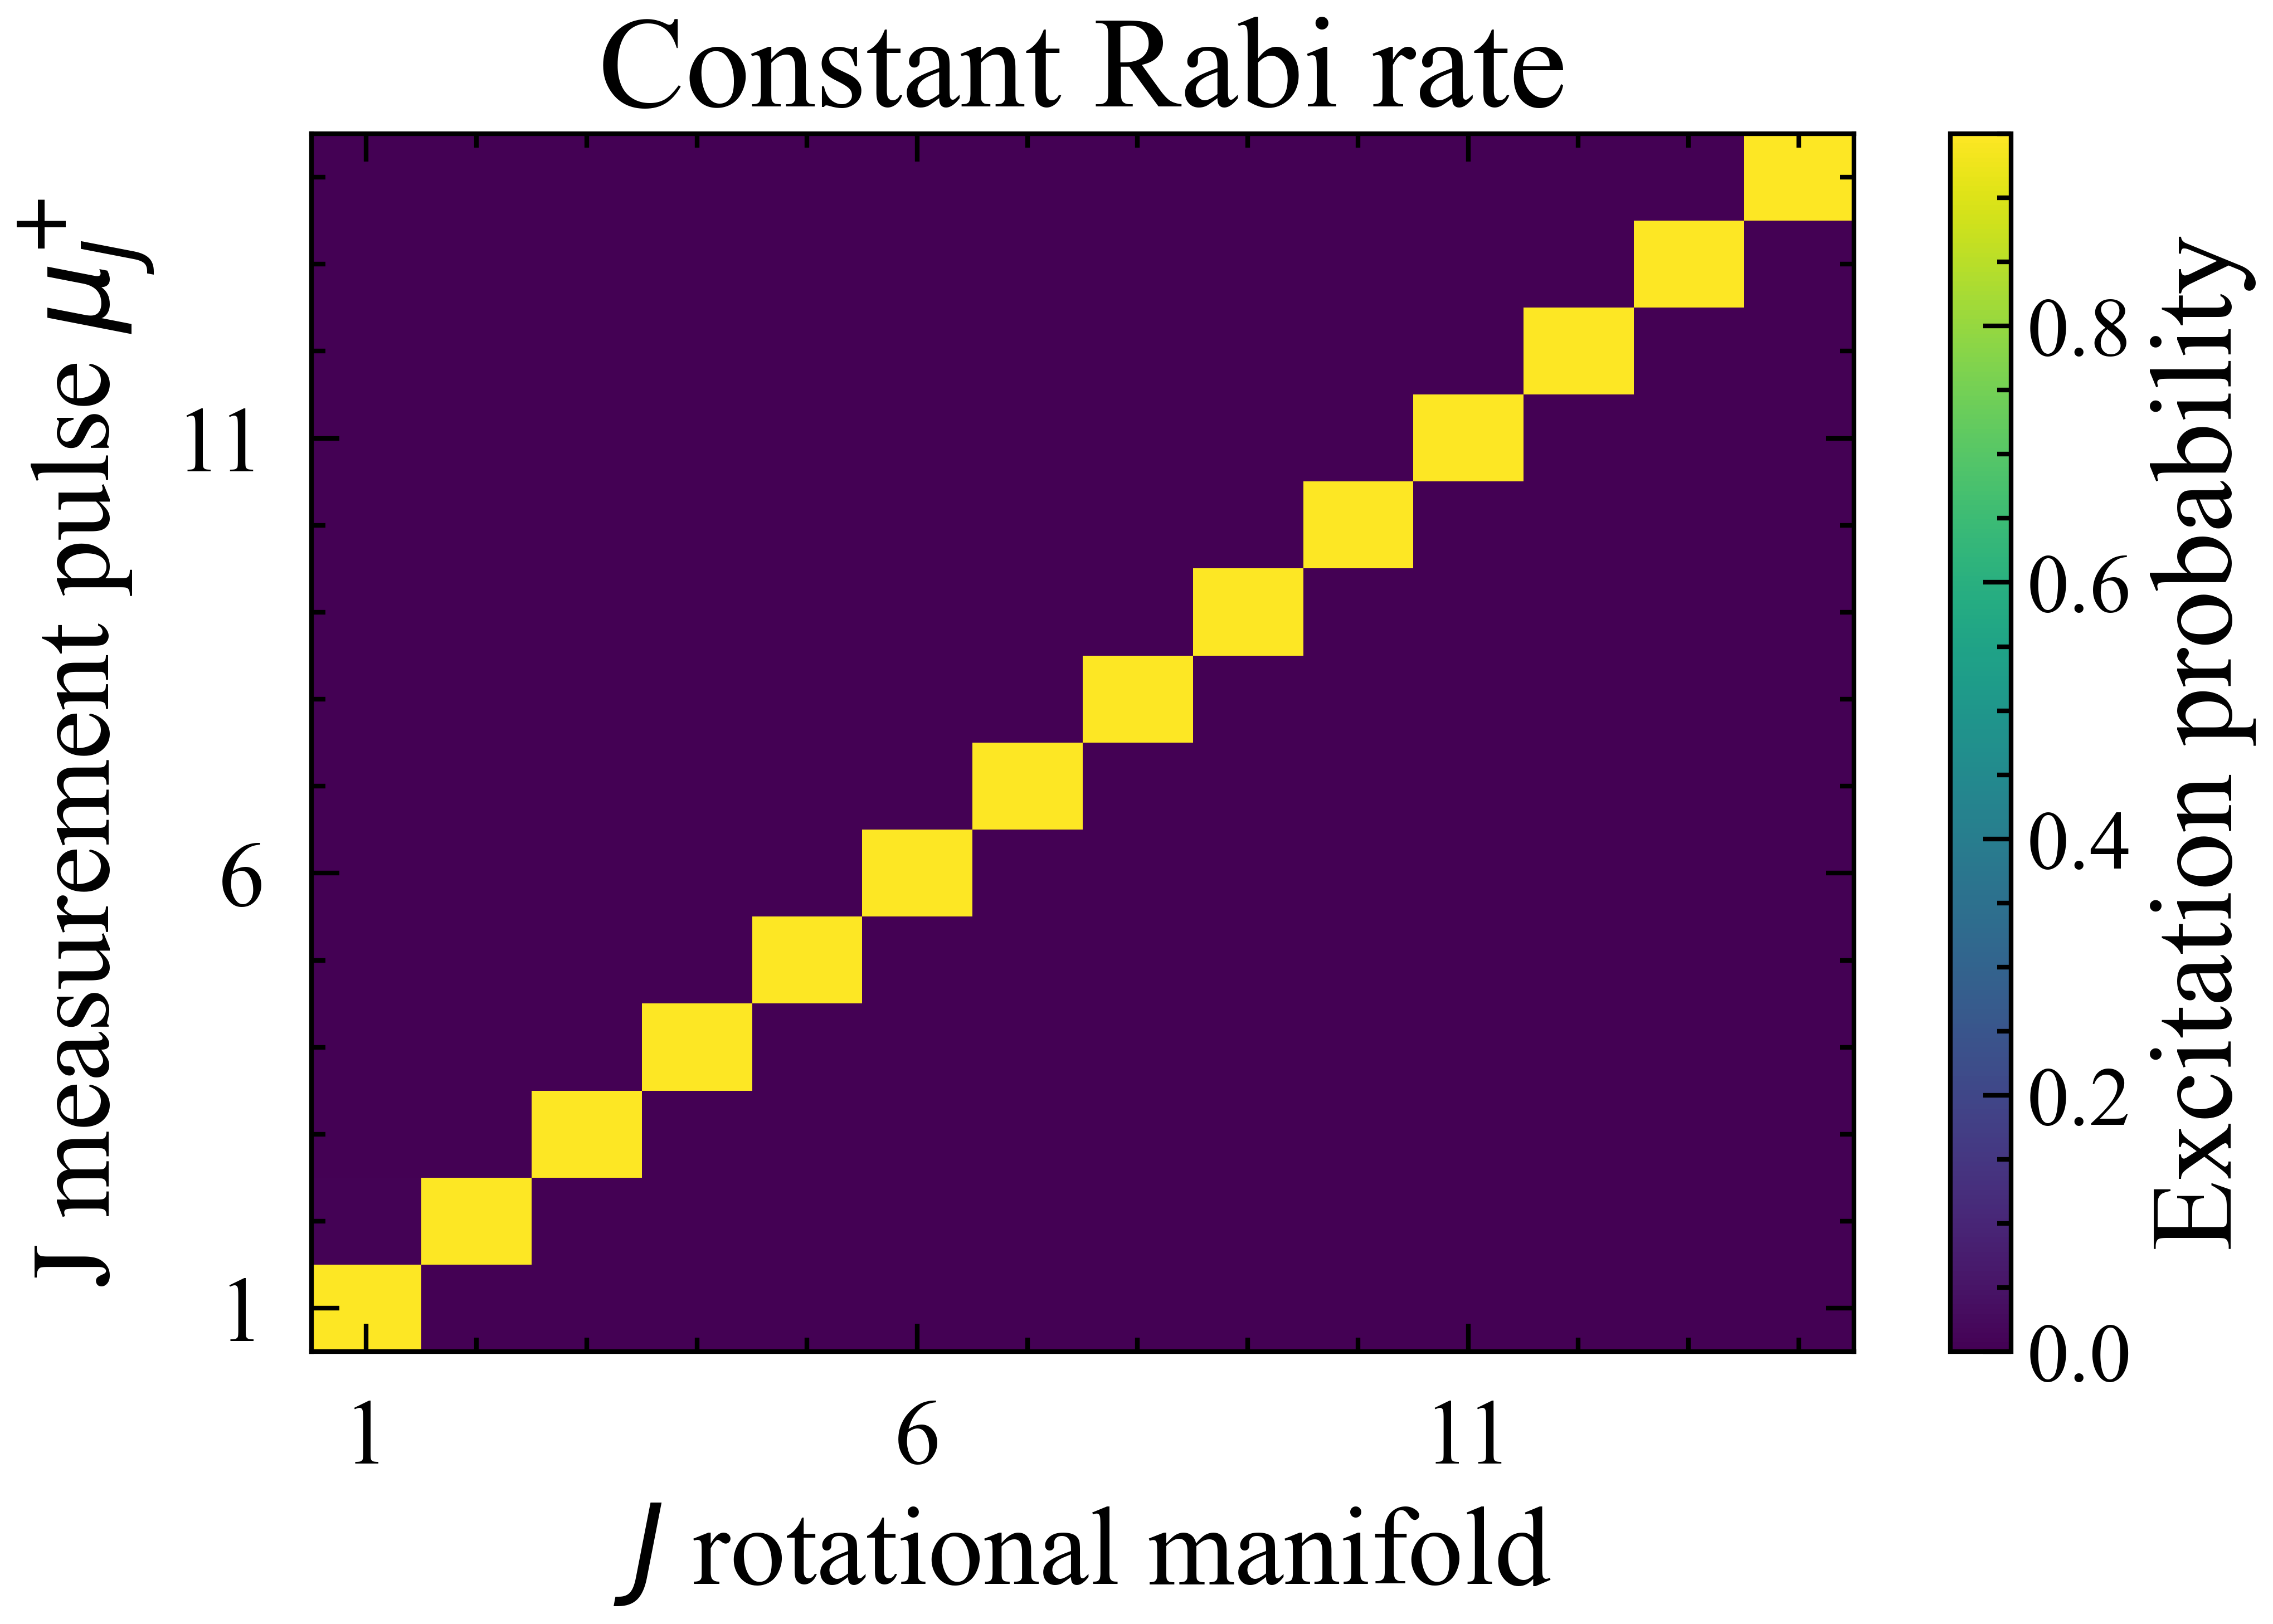

In [5]:
meas_sensitivity_heatmap(Estimator, 
                         indices_penultimate_upper, 
                         indices_leftmost, 
                         figname="meas_cah_0-1_constRR.svg",
                         title="Constant Rabi rate")

# CaOH

In [6]:
b_field_gauss = 3.27
j_max = 50
temperature = 300

molecule = CaOH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = States(molecule, temperature)

Saved molecule data in:
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_states.csv
/home/stripzio/bayesian-qls/project/molecule_data/CaOH_B[3.27]_Jmax[50]_transitions.csv


In [7]:
indices_leftmost = [2*(2*j+1) for j in range(j_max)]
indices_leftmost = [0] + list(accumulate(indices_leftmost))

lower_indices = [idx + (2*i+1) for i, idx in enumerate(indices_leftmost)]

indices_penultimate_upper = [ind+1 for ind in indices_leftmost] 
indices_thirdultimate_upper = [ind+2 for ind in indices_leftmost]
indices_fourthultimate_upper = [ind+3 for ind in indices_leftmost]
indices_fifthultimate_upper = [ind+4 for ind in indices_leftmost]
indices_sixthultimate_upper = [ind+5 for ind in indices_leftmost]

In [8]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)


rabi_by_j = 2 * np.pi * 0.005
dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.95,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_0-1_constRR.svg


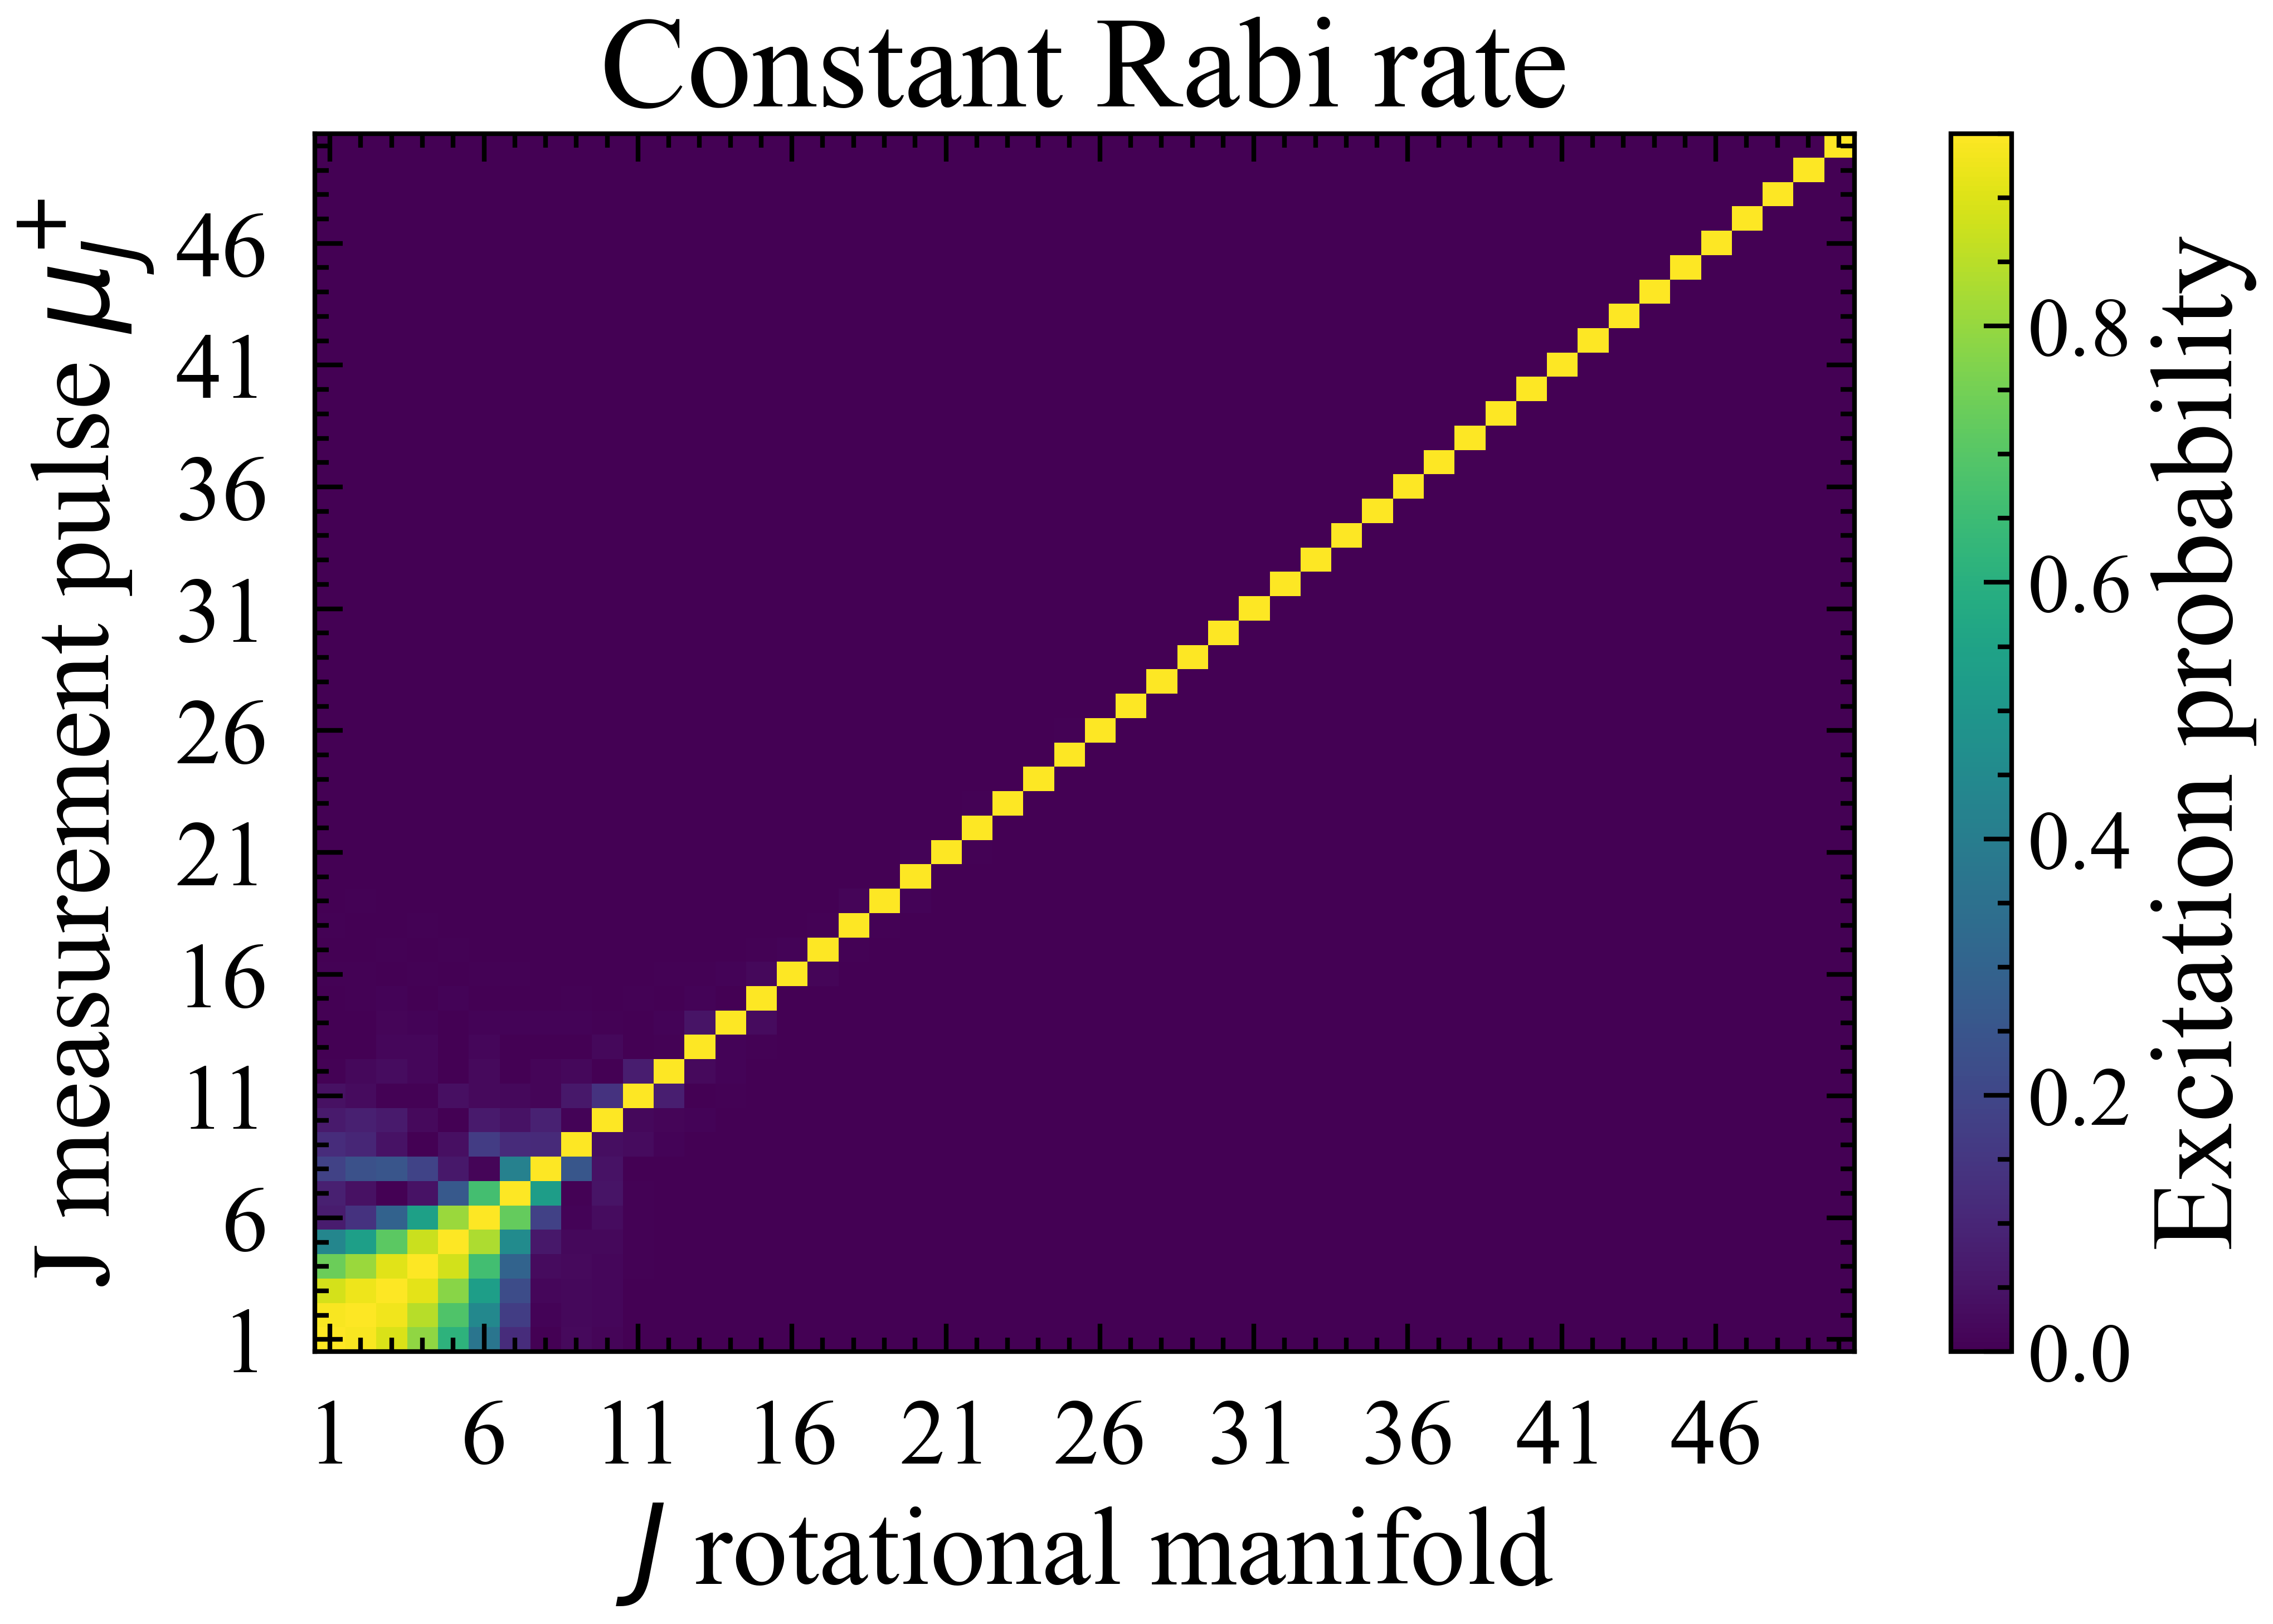

In [9]:
meas_sensitivity_heatmap(Estimator, 
                         indices_penultimate_upper, 
                         indices_leftmost, 
                         figname="meas_caoh_0-1_constRR.svg",
                         title="Constant Rabi rate")

In [10]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)


rabi_by_j = {
    (1, 10): 2 * np.pi * 0.0001,     
    (11, 36): 2 * np.pi * 0.001,    
    (37, 50): 2 * np.pi * 0.005     
}


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.9,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_0-1_JdepRR.svg


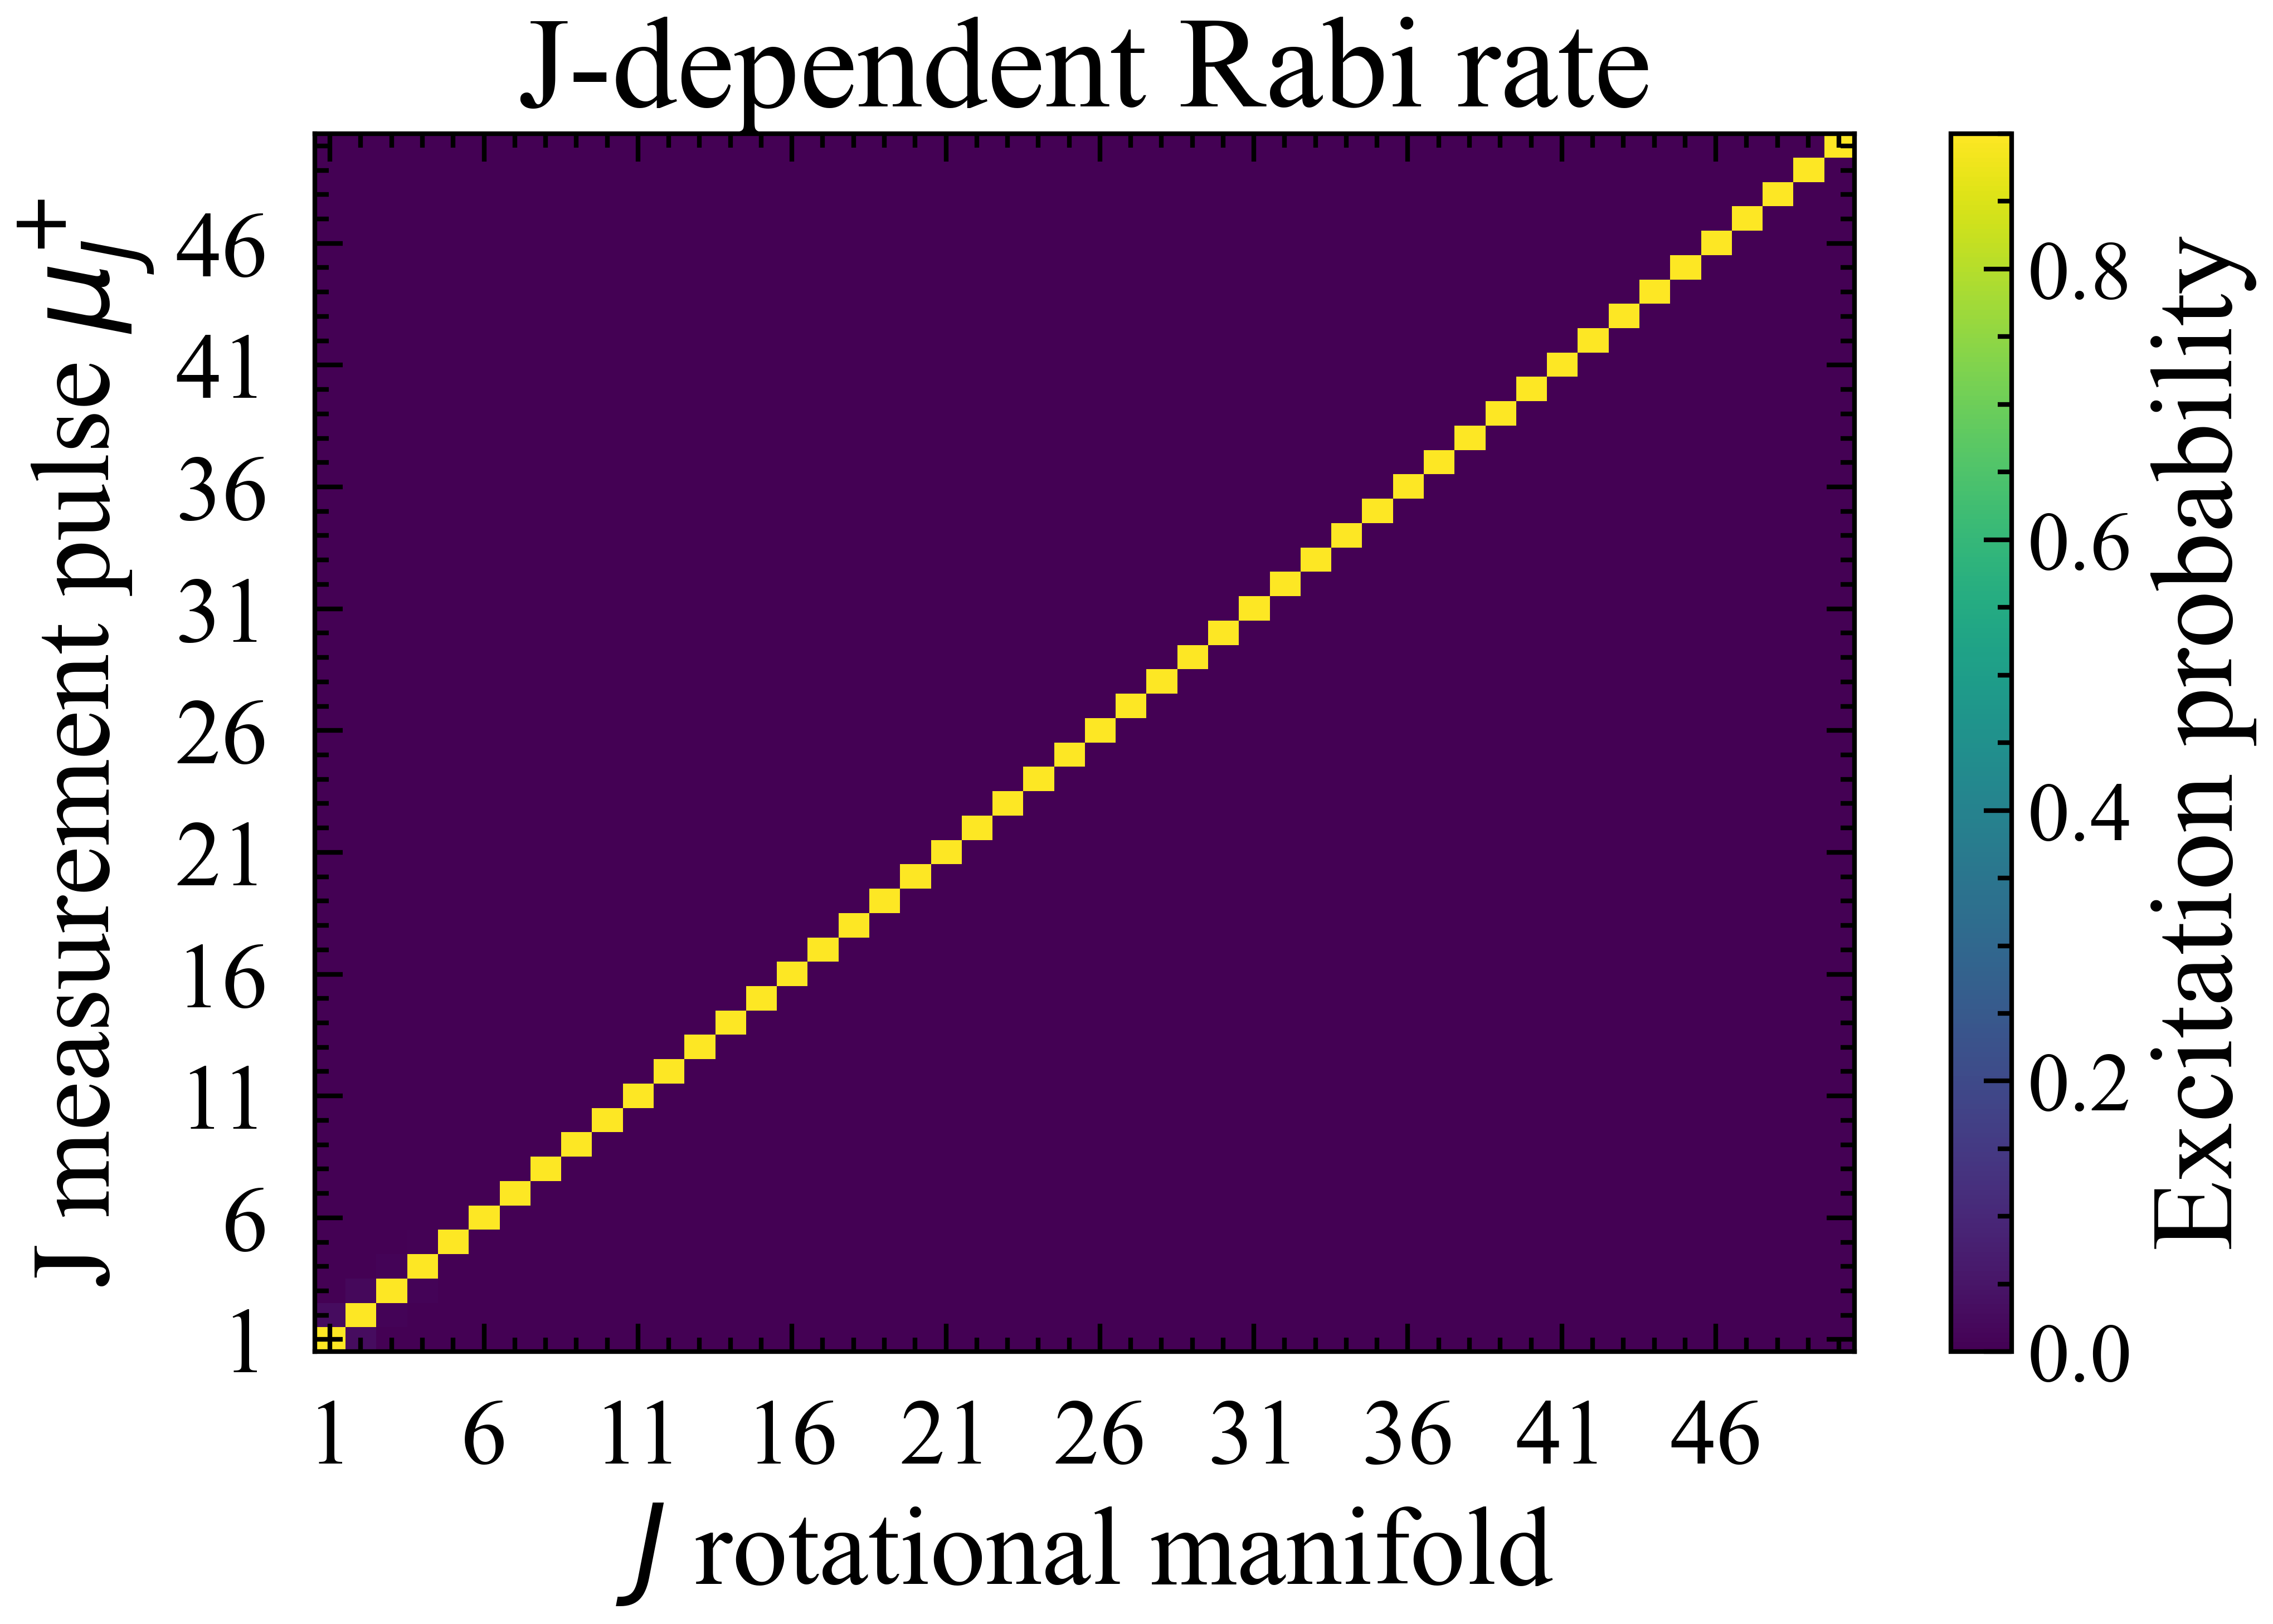

In [11]:
meas_sensitivity_heatmap(Estimator, 
                         indices_penultimate_upper, 
                         indices_leftmost, 
                         figname="meas_caoh_0-1_JdepRR.svg",
                         title = "J-dependent Rabi rate")


## Other transitions are investigated

Measurement pulses sensitivity on other transitions that can lead to positive rates

### $|J;-m+1/2;- \rangle$ to $|J;-m+3/2;- \rangle$

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_1-2_constRR.svg


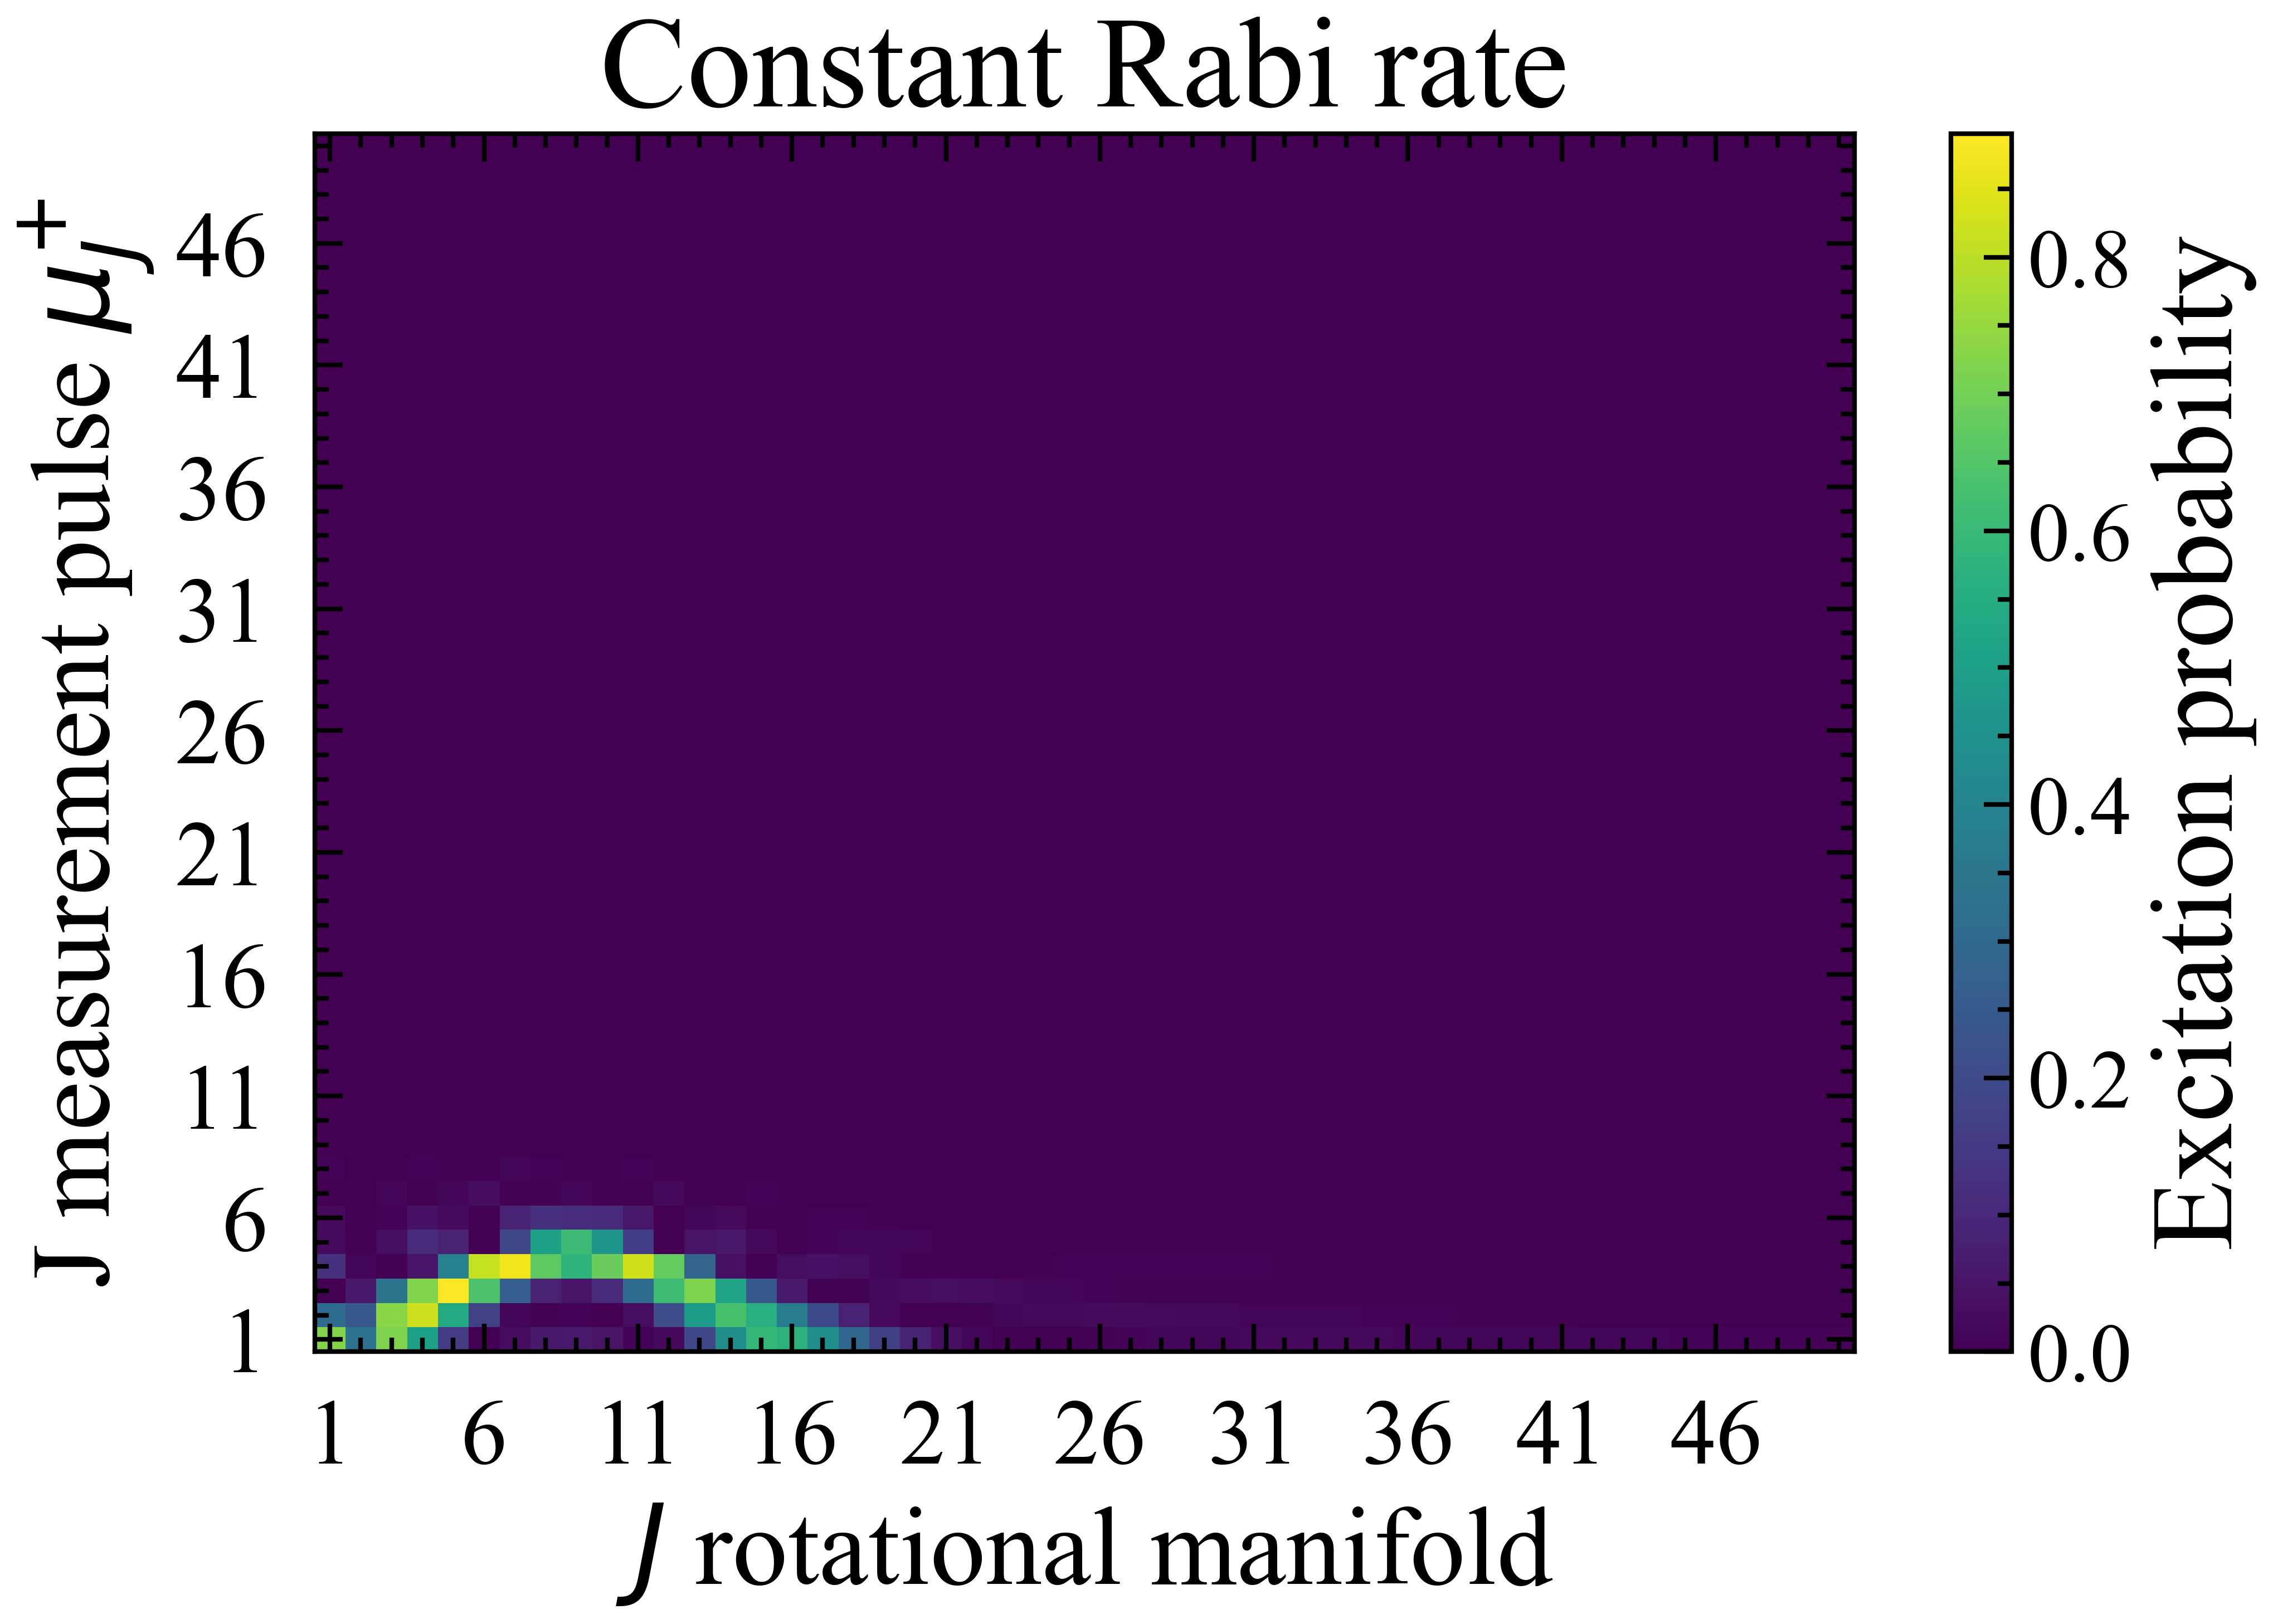

In [12]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)



rabi_by_j = 2 * np.pi * 0.001
dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.9,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

meas_sensitivity_heatmap(Estimator,
                         indices_thirdultimate_upper, 
                         indices_penultimate_upper,
                         figname="meas_caoh_1-2_constRR.svg",
                         title = "Constant Rabi rate")

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_1-2_JdepRR.svg


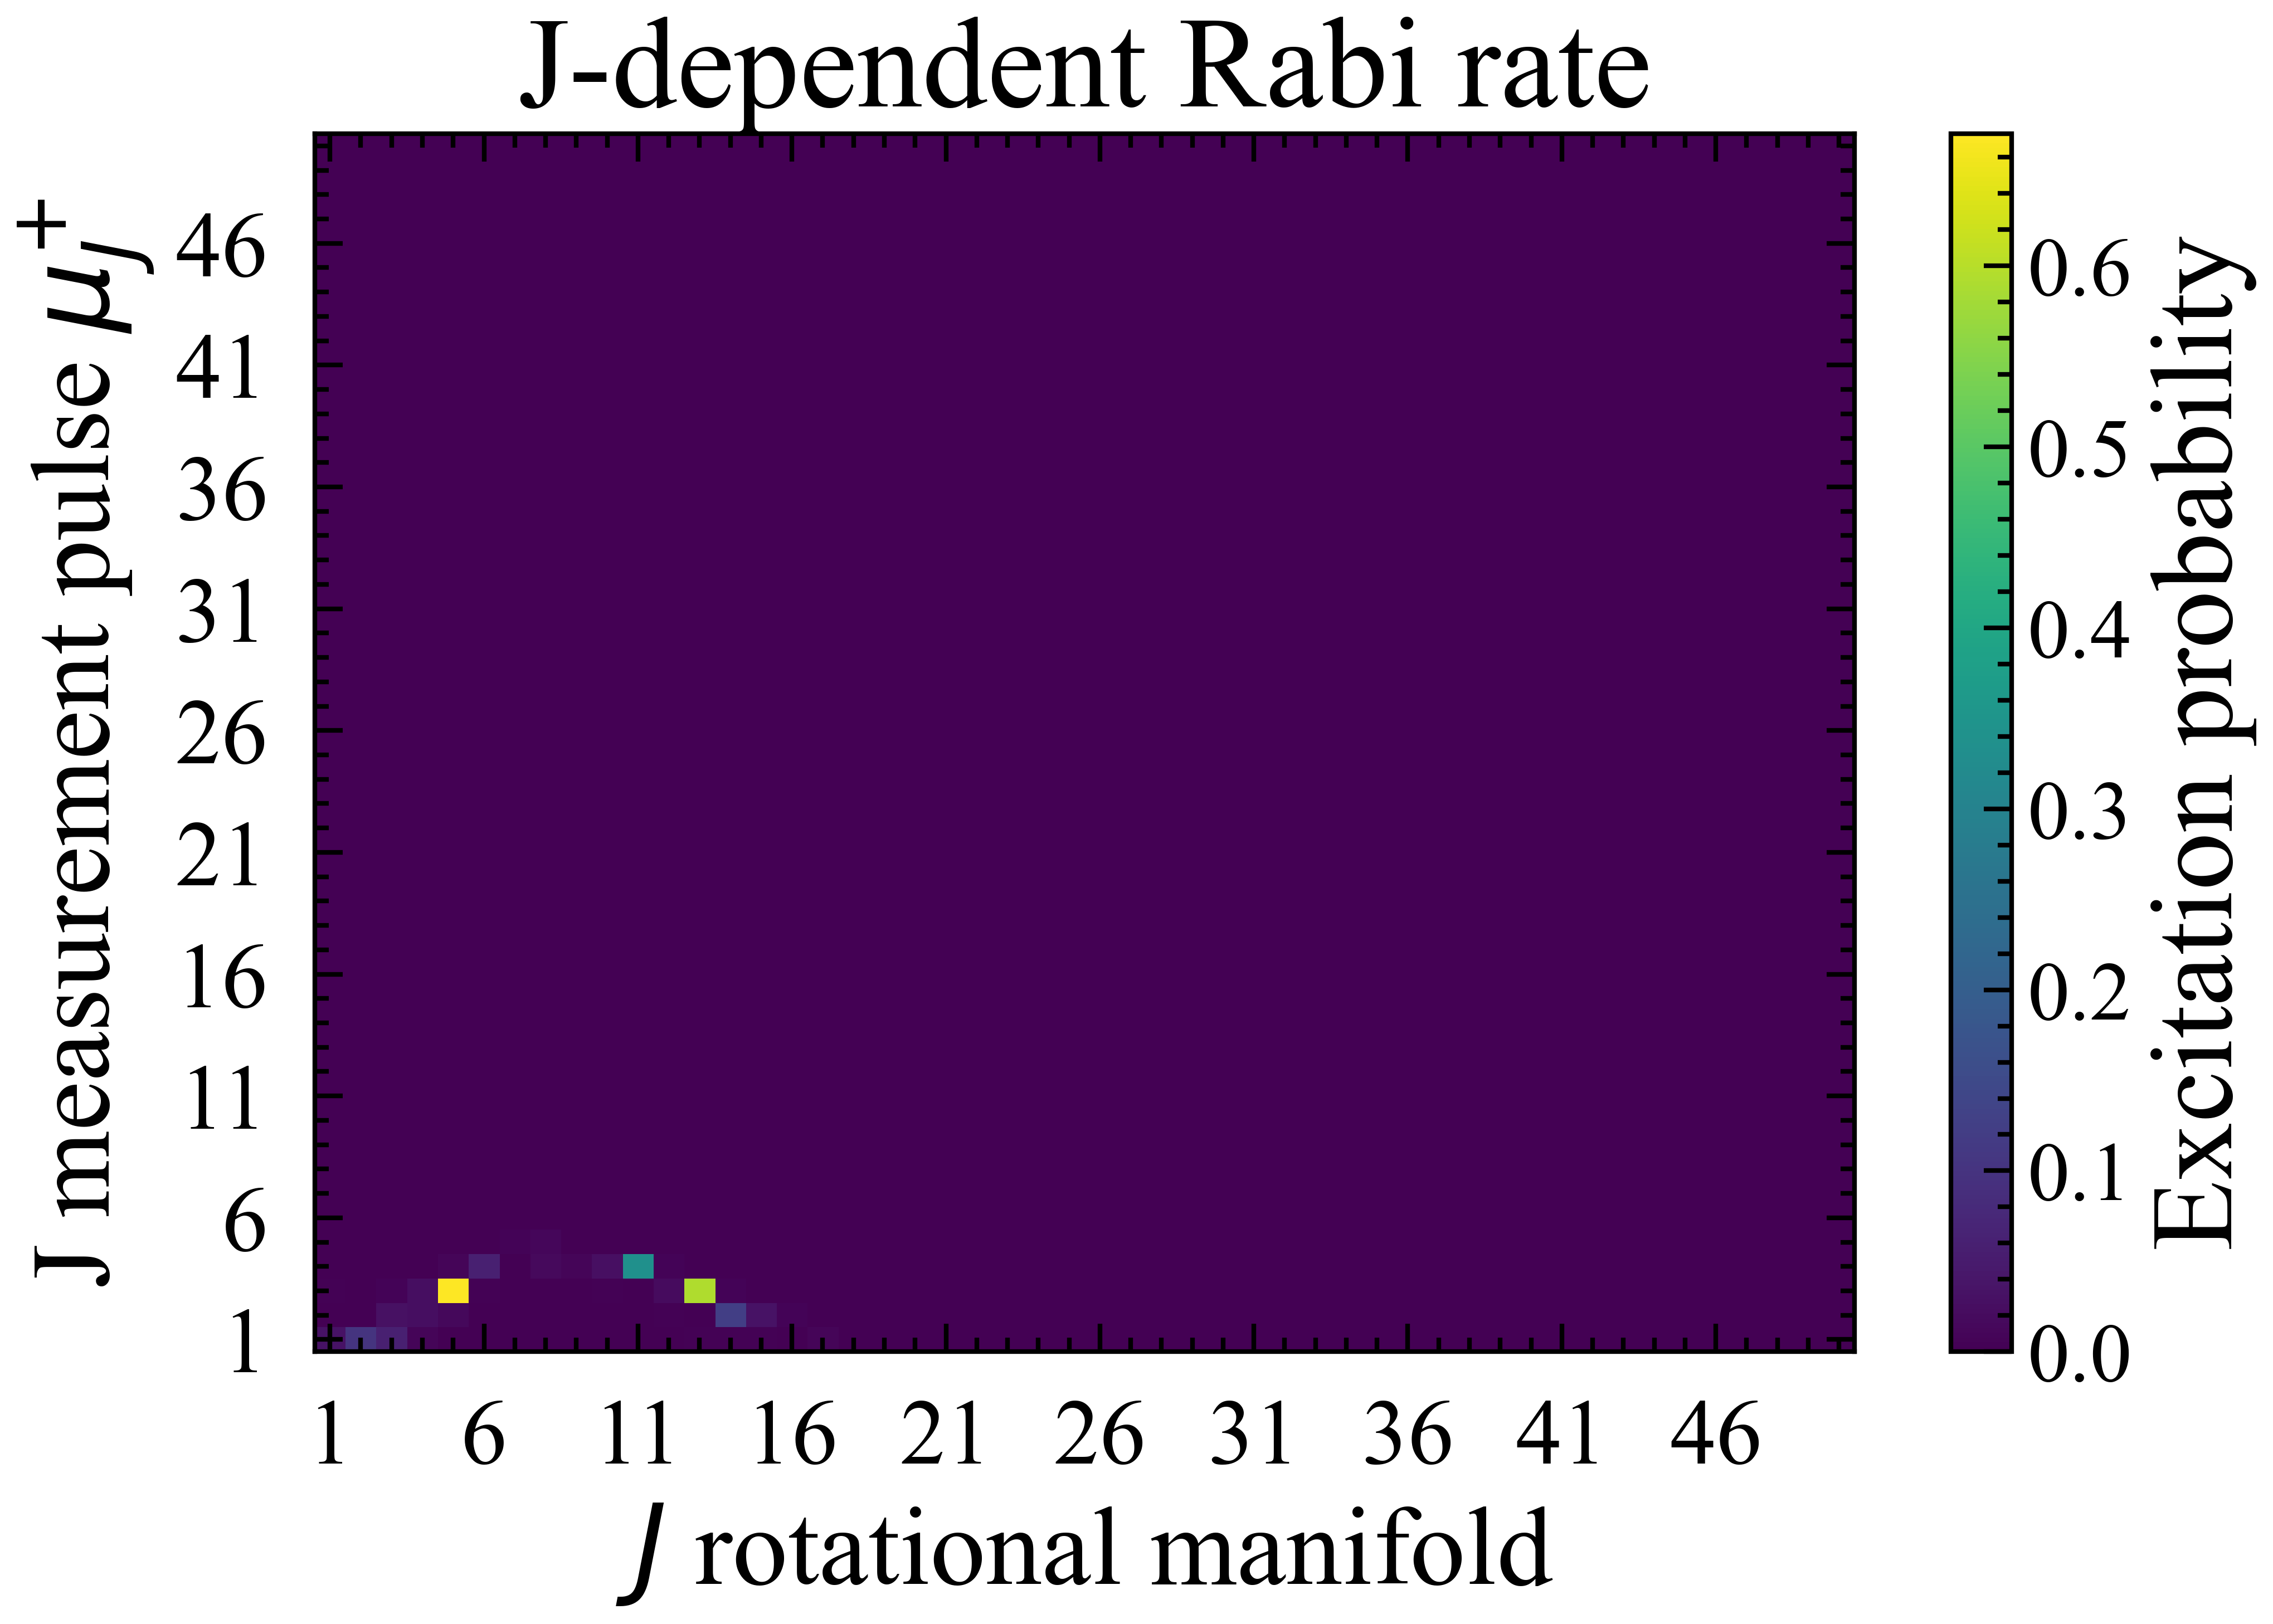

In [13]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)


rabi_by_j = {
    (1, 10): 2 * np.pi * 0.0001,     
    (11, 36): 2 * np.pi * 0.001,    
    (37, 50): 2 * np.pi * 0.005     
}

dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.9,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

meas_sensitivity_heatmap(Estimator,
                         indices_thirdultimate_upper, 
                         indices_penultimate_upper,
                         figname="meas_caoh_1-2_JdepRR.svg",
                         title = "J-dependent Rabi rate")

### $|J;-m+3/2;- \rangle$ to $|J;-m+5/2;- \rangle$

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_2-3_constRR.svg


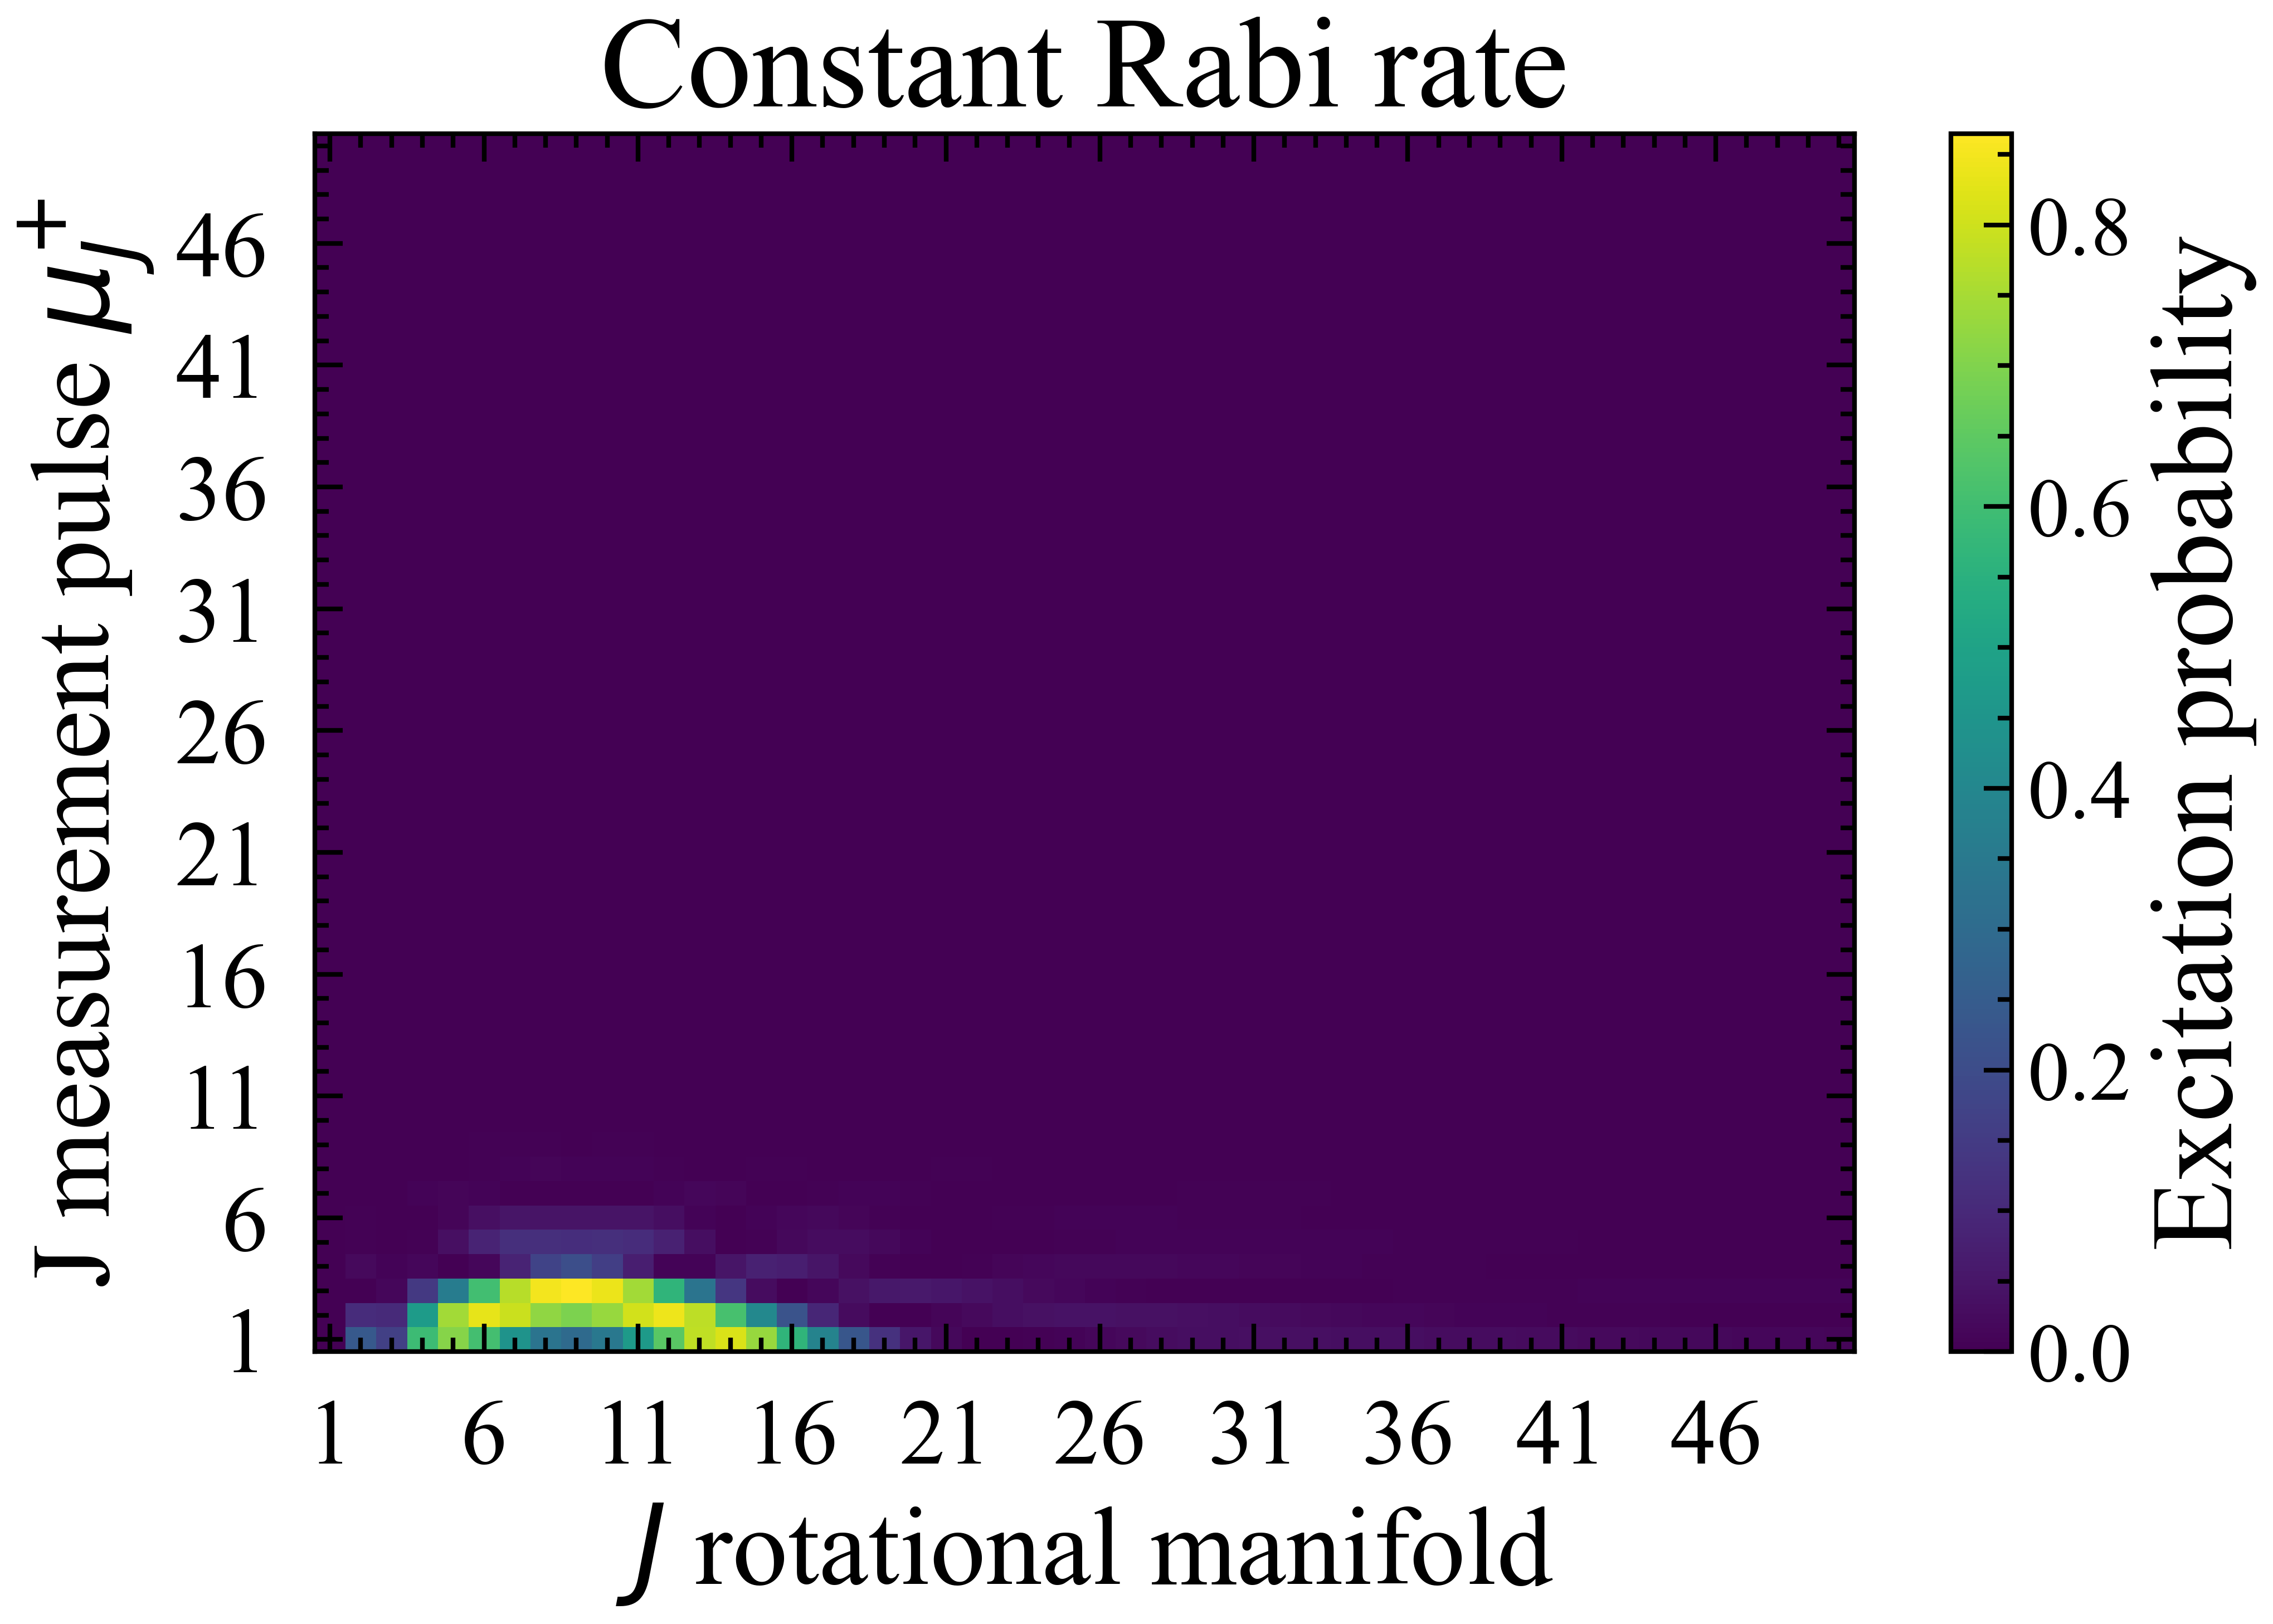

In [14]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)


rabi_by_j = 2 * np.pi * 0.001
dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.9,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

meas_sensitivity_heatmap(Estimator, 
                         indices_fourthultimate_upper, 
                         indices_thirdultimate_upper,
                         figname="meas_caoh_2-3_constRR.svg",
                         title = "Constant Rabi rate")

Saved figure in: /home/stripzio/bayesian-qls/project/images/meas_caoh_2-3_JdepRR.svg


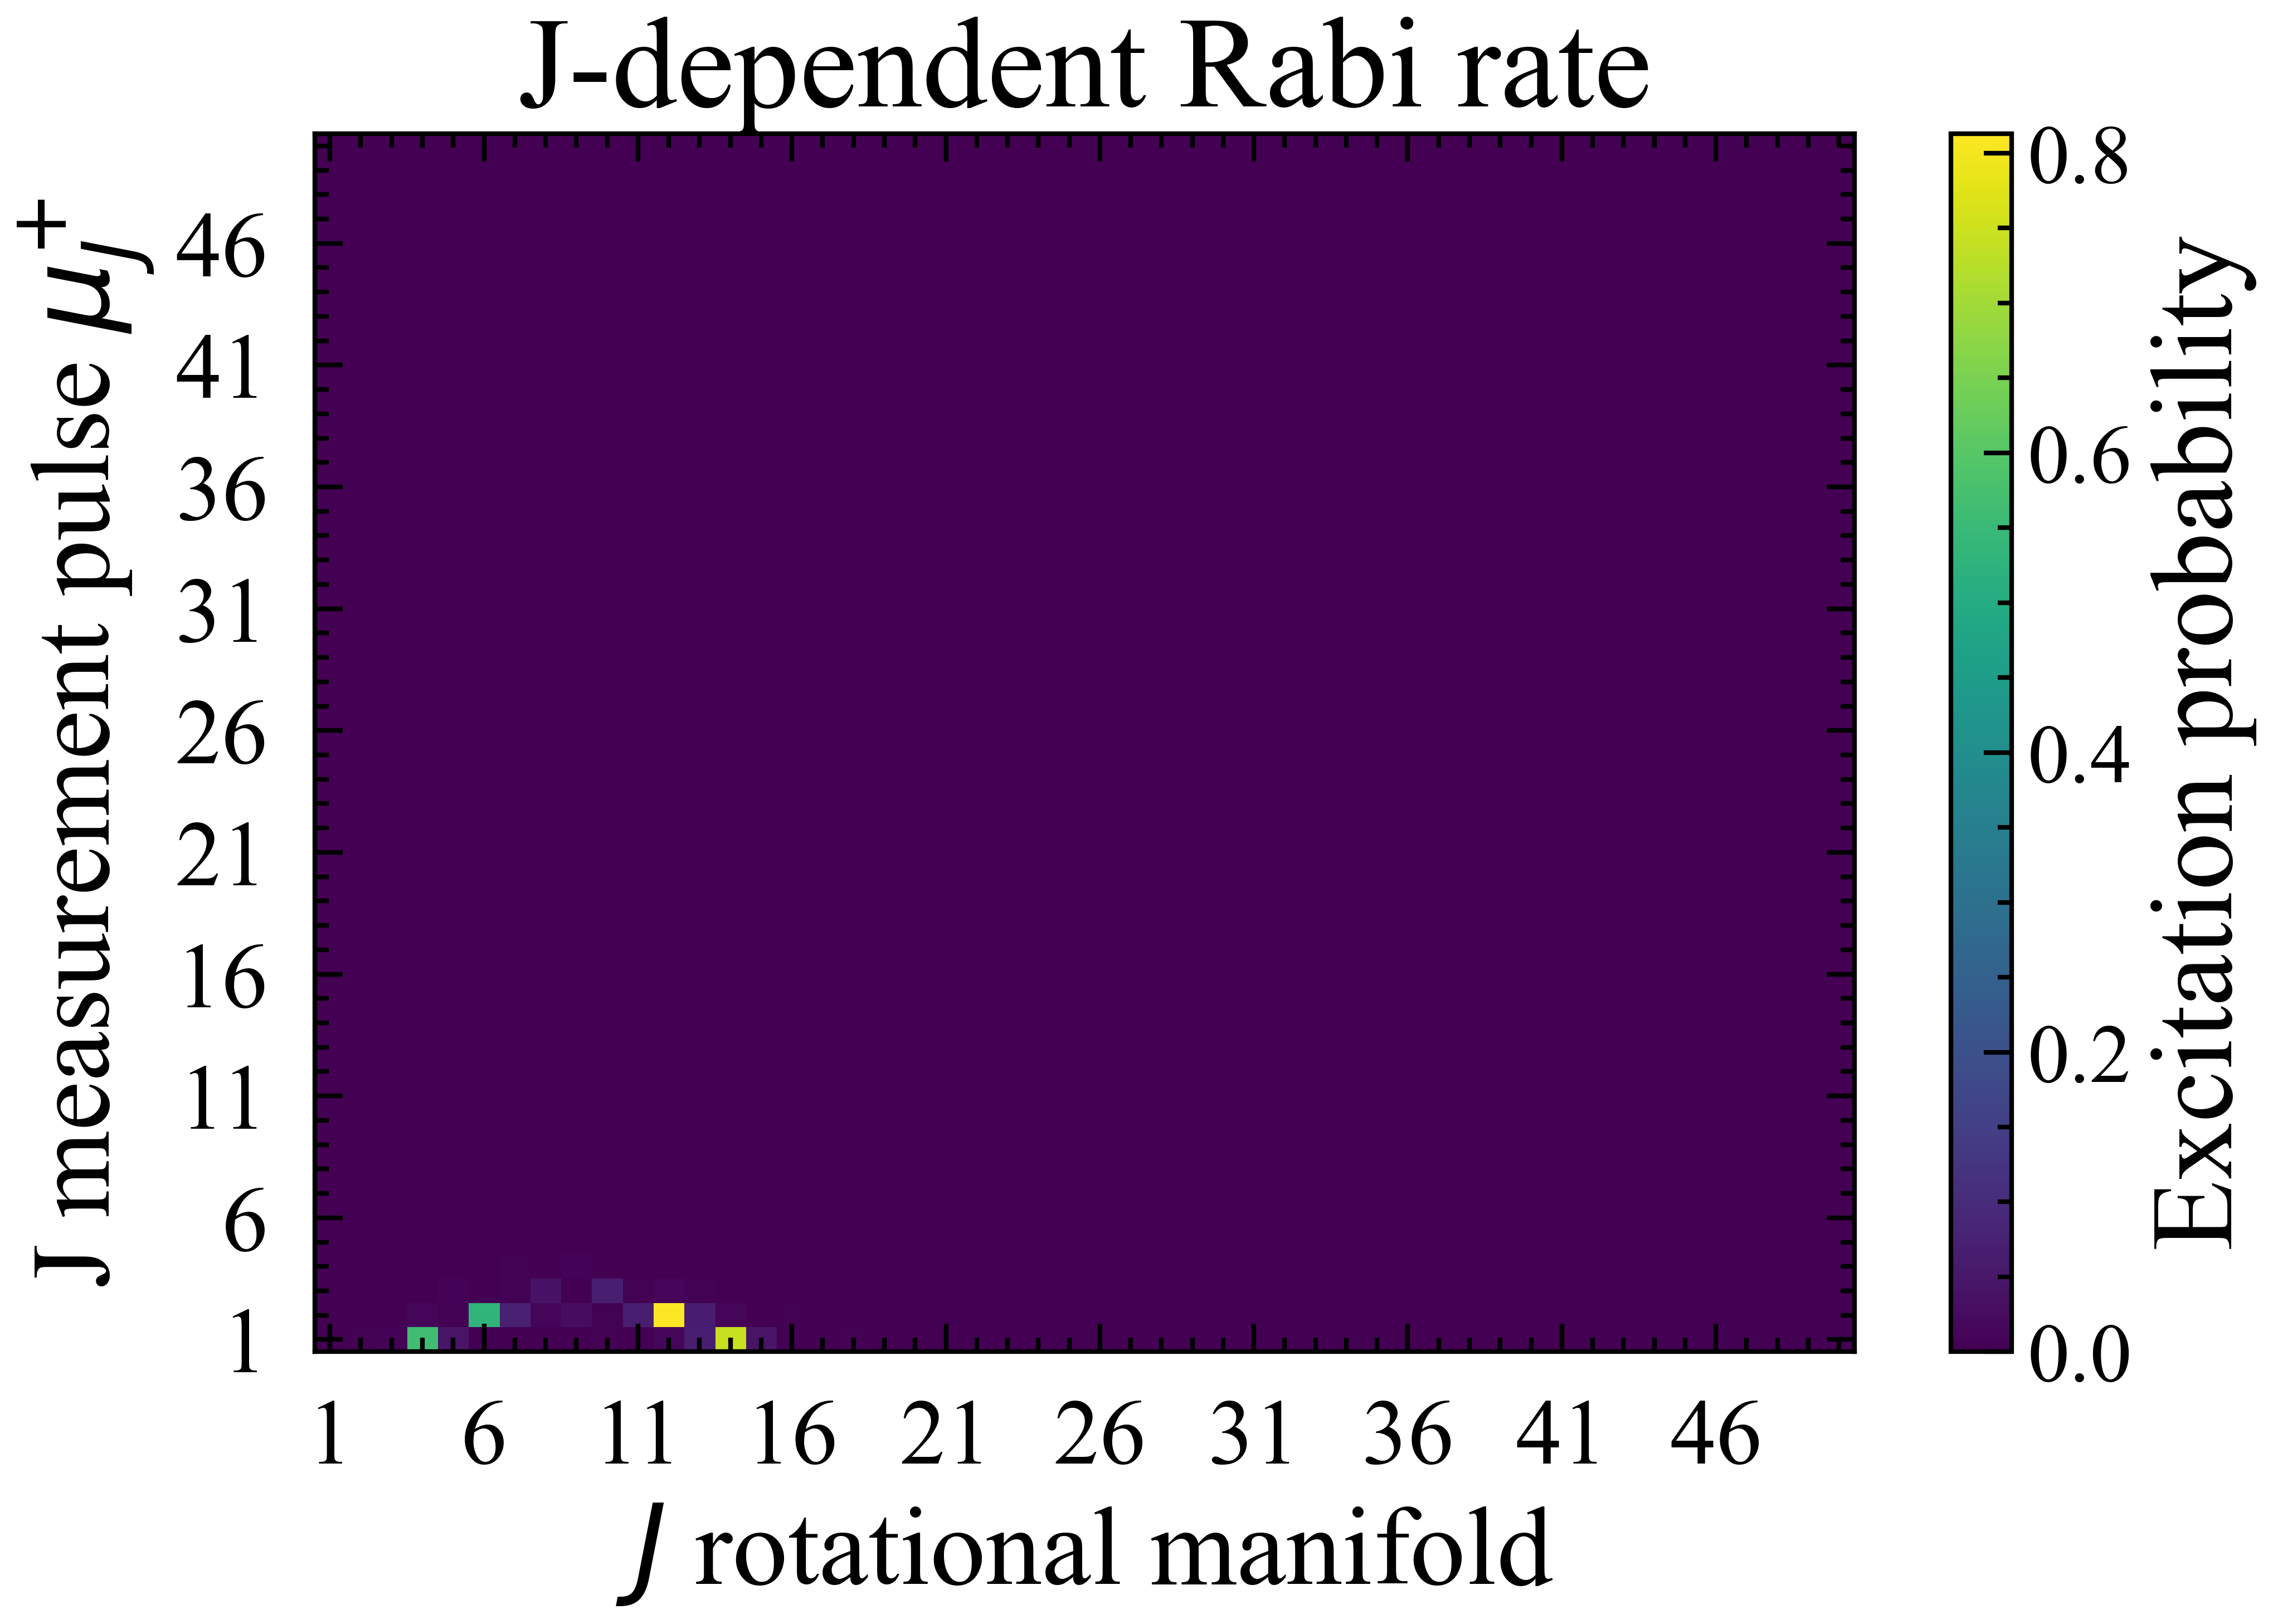

In [15]:
Estimator = BayesianStateEstimation(model=molecule, temperature=temperature, b_field_gauss=b_field_gauss, j_max=j_max)


rabi_by_j = {
    (1, 10): 2 * np.pi * 0.0001,     
    (11, 36): 2 * np.pi * 0.001,    
    (37, 50): 2 * np.pi * 0.005     
}

dephased = False
coherence_time_us = 1000
is_minus = False


Estimator.measurement_setting(
        rabi_by_j=rabi_by_j, 
        dephased=dephased, 
        coherence_time_us=coherence_time_us, 
        is_minus=is_minus, 
        noise_params=None, 
        seed=None, 
        max_excitation=0.9,
        laser_miscalibration=None,
        seed_miscalibration=None,
        marginalization=False
)

meas_sensitivity_heatmap(Estimator, 
                         indices_fourthultimate_upper, 
                         indices_thirdultimate_upper,
                         figname="meas_caoh_2-3_JdepRR.svg",
                         title = "J-dependent Rabi rate")